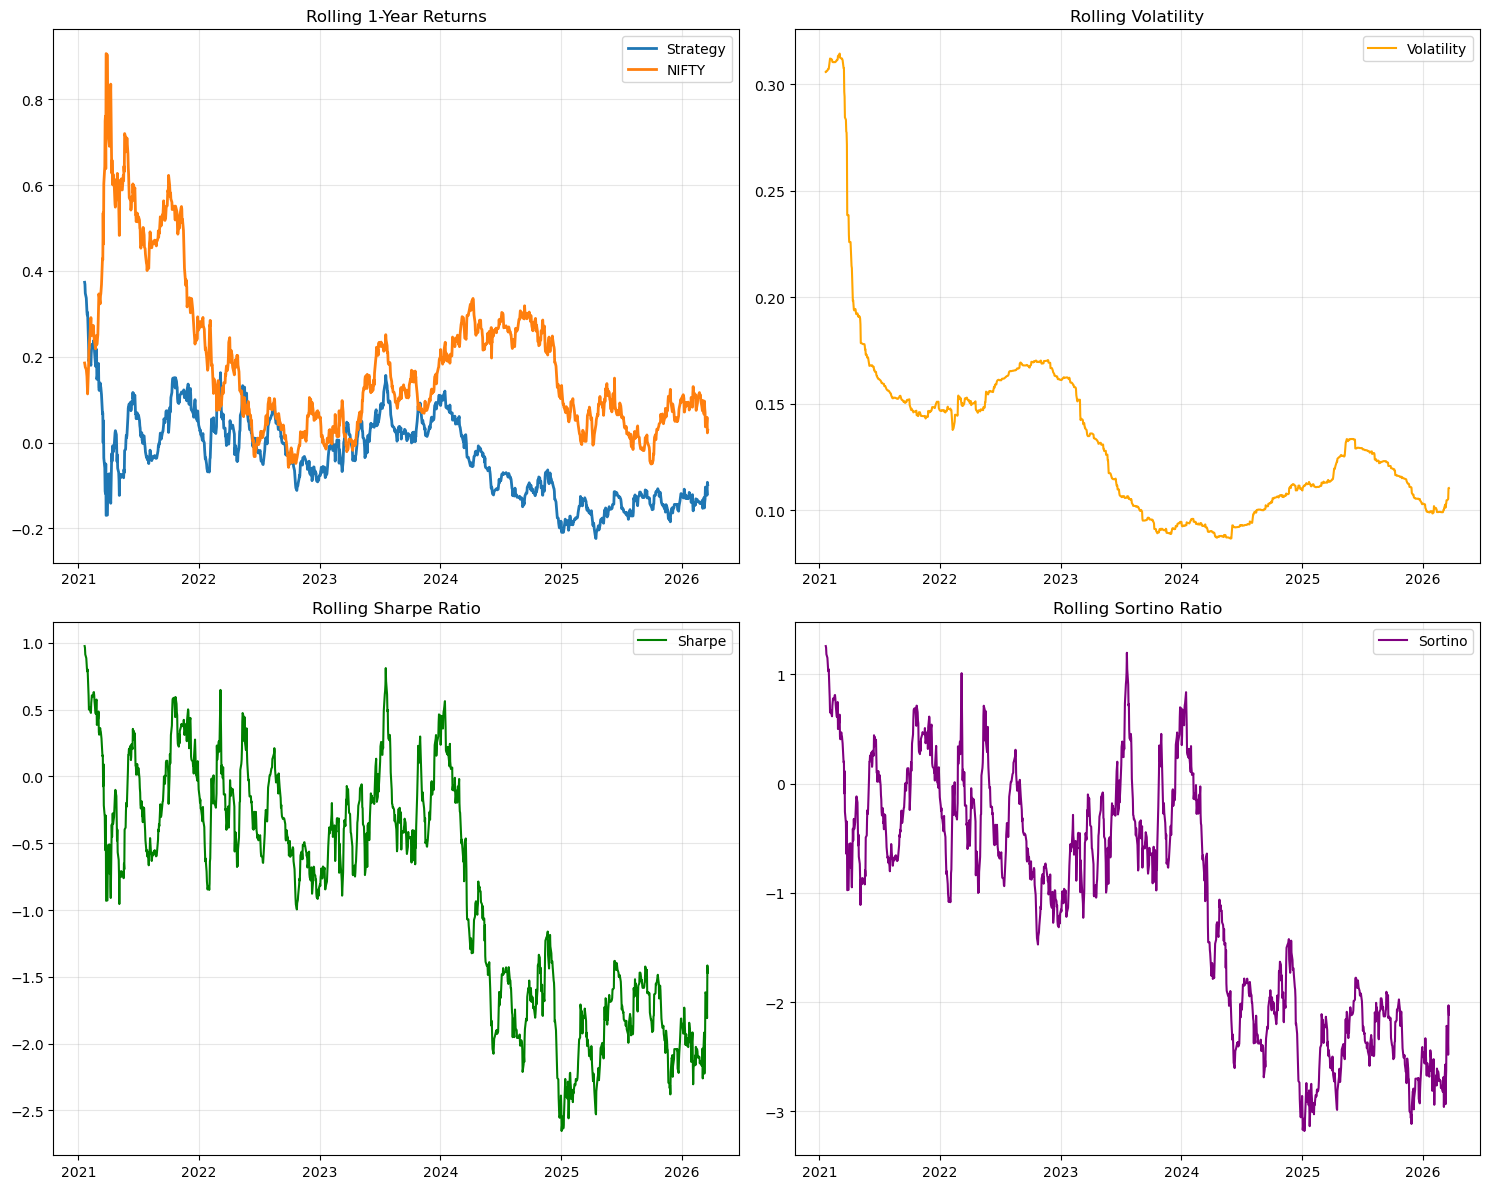

=== ROLLING METRICS (LATEST) ===
Strategy Return: -9.82%
NIFTY Return:   2.87%
CAGR:           -9.82%
Sharpe:         -1.469
Sortino:        -2.114
Volatility:     11.04%
Drawdown:       -33.91%


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# 1. LOAD DATA
# =============================================
market = pd.read_csv("../backtesting/market_backtest_v4.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

strategy_ret = market["strategy_ret_v2"]
benchmark_ret = market["nifty_ret"]

# =============================================
# 2. PARAMETERS
# =============================================
window = 252  # 1 year
rf_daily = 0.065 / 252

# =============================================
# 3. ROLLING METRICS
# =============================================

# Rolling Return
market["rolling_return"] = (
    (1 + strategy_ret).rolling(window).apply(np.prod, raw=True) - 1
)

market["rolling_benchmark"] = (
    (1 + benchmark_ret).rolling(window).apply(np.prod, raw=True) - 1
)

# Rolling CAGR (better interpretation)
market["rolling_cagr"] = (
    (1 + strategy_ret).rolling(window).apply(np.prod, raw=True) ** (252/window) - 1
)

# Rolling Volatility
market["rolling_vol"] = strategy_ret.rolling(window).std() * np.sqrt(252)

# Rolling Sharpe (safe version)
rolling_std = strategy_ret.rolling(window).std()

market["rolling_sharpe"] = np.where(
    rolling_std != 0,
    ((strategy_ret.rolling(window).mean() - rf_daily) / rolling_std) * np.sqrt(252),
    0
)

# Rolling Sortino
def rolling_sortino(returns, window, rf=rf_daily):
    def sortino_func(x):
        downside = x[x < 0]
        if len(downside) == 0 or downside.std() == 0:
            return 0
        return (x.mean() - rf) / downside.std() * np.sqrt(252)
    return returns.rolling(window).apply(sortino_func, raw=True)

market["rolling_sortino"] = rolling_sortino(strategy_ret, window)

# Rolling Drawdown
market["rolling_drawdown"] = (
    market["strategy_equity"] / market["strategy_equity"].cummax() - 1
)

# =============================================
# 4. VISUALIZATION
# =============================================
plt.figure(figsize=(15, 12))

# 1. Rolling Return
plt.subplot(2, 2, 1)
plt.plot(market.index, market["rolling_return"], label="Strategy", linewidth=2)
plt.plot(market.index, market["rolling_benchmark"], label="NIFTY", linewidth=2)
plt.title("Rolling 1-Year Returns")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Rolling Volatility
plt.subplot(2, 2, 2)
plt.plot(market.index, market["rolling_vol"], label="Volatility", color='orange')
plt.title("Rolling Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Rolling Sharpe
plt.subplot(2, 2, 3)
plt.plot(market.index, market["rolling_sharpe"], label="Sharpe", color='green')
plt.title("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Rolling Sortino
plt.subplot(2, 2, 4)
plt.plot(market.index, market["rolling_sortino"], label="Sortino", color='purple')
plt.title("Rolling Sortino Ratio")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# 5. SUMMARY
# =============================================
print("=== ROLLING METRICS (LATEST) ===")
print(f"Strategy Return: {market['rolling_return'].iloc[-1]:.2%}")
print(f"NIFTY Return:   {market['rolling_benchmark'].iloc[-1]:.2%}")
print(f"CAGR:           {market['rolling_cagr'].iloc[-1]:.2%}")
print(f"Sharpe:         {market['rolling_sharpe'].iloc[-1]:.3f}")
print(f"Sortino:        {market['rolling_sortino'].iloc[-1]:.3f}")
print(f"Volatility:     {market['rolling_vol'].iloc[-1]:.2%}")
print(f"Drawdown:       {market['rolling_drawdown'].iloc[-1]:.2%}")

# =============================================
# 6. SAVE
# =============================================
market.to_csv("../backtesting/market_backtest_v6.csv")